<a href="https://colab.research.google.com/github/192512041simats-hari/IOE-AND-AI-SYSTEM/blob/main/EXP2%2Ca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

REAL-TIME ONLINE EXAM MONITORING USING MQTT
    Time  Focus Score  Tab Switches      Status
91    91        91.26            10  Suspicious
92    92        91.26            10  Suspicious
93    93        73.55             8  Suspicious
94    94        73.55             8  Suspicious
95    95        73.55             8  Suspicious

Average Focus Score : 78.41
Average Tab Switches: 4.56
Maximum Focus Score : 98.12
Minimum Focus Score : 61.5
Total Messages      : 96
Suspicious Cases    : 36


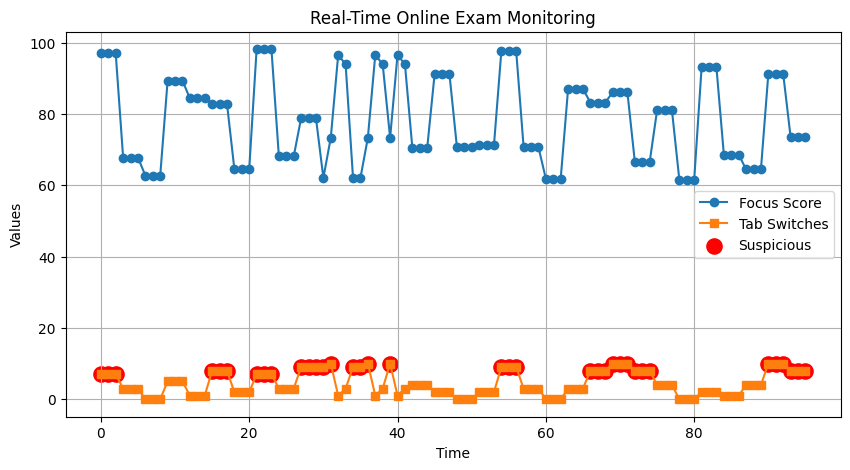


Monitoring stopped by user.


In [3]:
# ---------------- Install paho-mqtt if it is not installed ----------------
# Run this as ONE single cell in Colab. If you split it across cells and the
# kernel restarts (or the import cell hasn't been run yet), `mqtt` will not
# exist and you'll hit: NameError: name 'mqtt' is not defined.
import sys
import subprocess
import importlib

def ensure_paho_mqtt():
    try:
        import paho.mqtt.client as mqtt_module
        return mqtt_module
    except ModuleNotFoundError:
        pass

    print("Installing paho-mqtt ...")
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "paho-mqtt"],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print(result.stdout)
        print(result.stderr)
        raise RuntimeError("pip install paho-mqtt failed - see output above")

    importlib.invalidate_caches()  # make sure Python sees the freshly installed package
    try:
        import paho.mqtt.client as mqtt_module
        return mqtt_module
    except ModuleNotFoundError as e:
        raise RuntimeError(
            "paho-mqtt installed but still not importable. "
            "In Colab, go to Runtime > Restart session, then run this cell again."
        ) from e

mqtt = ensure_paho_mqtt()
print("paho-mqtt loaded OK, version:", getattr(mqtt, "__version__", "unknown"))

import json
import random
import threading
import time
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output

# ---------------- MQTT Configuration ----------------
BROKER = "broker.hivemq.com"
PORT = 1883
TOPIC = "IoT_AI_LAB/OnlineExamMonitoring"

# ---------------- Data Storage ----------------
focus_data = []
tabswitch_data = []
timestamps = []
lock = threading.Lock()  # protect shared lists across threads

# ---------------- Client Creation (version-safe) ----------------
def make_client():
    # Only paho-mqtt >= 2.0 has CallbackAPIVersion at all
    if hasattr(mqtt, "CallbackAPIVersion"):
        return mqtt.Client(mqtt.CallbackAPIVersion.VERSION1)
    return mqtt.Client()

publisher = make_client()
subscriber = make_client()

# ---------------- Publisher ----------------
def start_publisher():
    try:
        publisher.connect(BROKER, PORT, 60)
    except Exception as e:
        print("Publisher connect failed:", e)
        return
    while True:
        try:
            focus = round(random.uniform(60, 100), 2)
            tabswitch = random.randint(0, 10)
            payload = {"focus_score": focus, "tab_switches": tabswitch}
            publisher.publish(TOPIC, json.dumps(payload))
        except Exception as e:
            print("Publish error:", e)
        time.sleep(1)

# ---------------- Subscriber Callbacks ----------------
def on_connect(client, userdata, flags, rc):
    print("Connected with result code", rc)
    client.subscribe(TOPIC)

def on_message(client, userdata, msg):
    try:
        data = json.loads(msg.payload.decode())
        if "focus_score" not in data or "tab_switches" not in data:
            return  # ignore messages not from our publisher
        with lock:
            focus_data.append(data["focus_score"])
            tabswitch_data.append(data["tab_switches"])
            timestamps.append(len(timestamps))
    except (json.JSONDecodeError, UnicodeDecodeError, KeyError):
        pass  # ignore malformed / unrelated messages on the shared public broker

subscriber.on_connect = on_connect
subscriber.on_message = on_message

try:
    subscriber.connect(BROKER, PORT, 60)
except Exception as e:
    print("Subscriber connect failed:", e)
    raise SystemExit(1)

threading.Thread(target=start_publisher, daemon=True).start()
threading.Thread(target=subscriber.loop_forever, daemon=True).start()

# ---------------- Live Dashboard Loop ----------------
try:
    while True:
        with lock:
            n = len(focus_data)
        if n >= 5:
            clear_output(wait=True)
            with lock:
                df = pd.DataFrame({
                    "Time": timestamps.copy(),
                    "Focus Score": focus_data.copy(),
                    "Tab Switches": tabswitch_data.copy()
                })
            df["Status"] = df["Tab Switches"].apply(
                lambda x: "Suspicious" if x > 5 else "Normal"
            )

            print("=" * 60)
            print("REAL-TIME ONLINE EXAM MONITORING USING MQTT")
            print("=" * 60)
            print(df.tail())
            print("\nAverage Focus Score :", round(df["Focus Score"].mean(), 2))
            print("Average Tab Switches:", round(df["Tab Switches"].mean(), 2))
            print("Maximum Focus Score :", df["Focus Score"].max())
            print("Minimum Focus Score :", df["Focus Score"].min())
            print("Total Messages      :", len(df))
            print("Suspicious Cases    :", (df["Status"] == "Suspicious").sum())

            fig = plt.figure(figsize=(10, 5))
            plt.plot(df["Time"], df["Focus Score"], marker='o', label="Focus Score")
            plt.plot(df["Time"], df["Tab Switches"], marker='s', label="Tab Switches")
            suspicious = df[df["Status"] == "Suspicious"]
            plt.scatter(
                suspicious["Time"],
                suspicious["Tab Switches"],
                color="red",
                s=120,
                label="Suspicious"
            )
            plt.title("Real-Time Online Exam Monitoring")
            plt.xlabel("Time")
            plt.ylabel("Values")
            plt.grid(True)
            plt.legend()
            plt.show()
            plt.close(fig)  # prevent "too many open figures" warning/error
        time.sleep(2)
except KeyboardInterrupt:
    print("\nMonitoring stopped by user.")